# Vertical (Xarray): interpolating from pressure to pressure levels

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

import earthkit.meteo.vertical.xarray as vertical

## Getting the data

The input is NetCDF data on pressure levels for multiple times. We fetch the data and load it into an Xarray.

In [2]:
ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
ds

era5_tquv_pl_subarea.nc:   0%|          | 0.00/14.6M [00:00<?, ?B/s]

<xarray.Dataset> Size: 35MB
Dimensions:         (valid_time: 4, pressure_level: 3, latitude: 301,
                     longitude: 601)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T10:30 GRIB to CDM+CF via cfgrib-0.9.1...

## Using interpolate_monotonic

In [3]:
# get dataarray for temperature on pressure levels
t = ds.t

# define the pressure coordinates of t (in Pa)
coords = t.pressure_level * 100  # hPa to Pa

# define the target pressure coordinates
target_coords = [87000.0, 90000]  # Pa

t_res = vertical.interpolate_monotonic(
    t,  # data to interpolate
    coords=t.pressure_level * 100,
    target_coords=target_coords,
    interpolation="log",
    vertical_dim="pressure_level",
)

# dump the result
t_res

<xarray.DataArray 't' (pressure_level: 2, valid_time: 4, latitude: 301,
                       longitude: 601)> Size: 6MB
array([[[[268.80438, 268.80438, 268.80438, ..., 268.80438, 268.80438,
          268.80438],
         [268.96716, 268.97284, 268.97708, ..., 268.8706 , 268.86777,
          268.86636],
         [269.39813, 269.4061 , 269.41602, ..., 269.07675, 269.0725 ,
          269.06628],
         ...,
         [292.64767, 292.67758, 292.7104 , ..., 299.59018, 299.24353,
          298.86963],
         [292.65625, 292.6461 , 292.67627, ..., 299.43314, 298.91785,
          298.5941 ],
         [292.65518, 292.59857, 292.64688, ..., 298.97372, 298.7429 ,
          298.5587 ]],

        [[267.9577 , 267.9577 , 267.9577 , ..., 267.9577 , 267.9577 ,
          267.9577 ],
         [267.7815 , 267.78717, 267.7923 , ..., 268.49957, 268.49673,
          268.4925 ],
         [267.50983, 267.52063, 267.53088, ..., 268.8865 , 268.87997,
          268.8743 ],
...
         [292.8984 , 292.83447, 292.9217 , ..., 305.53693, 305.3479 ,
          305.1117 ],
         [292.96344, 292.744  , 292.78485, ..., 303.21362, 303.451  ,
          302.9143 ],
         [293.06302, 292.83704, 292.7677 , ..., 298.51385, 299.11368,
          299.00436]],

        [[267.94824, 267.94824, 267.94824, ..., 267.94824, 267.94824,
          267.94824],
         [267.95895, 267.9596 , 267.96088, ..., 268.09116, 268.0899 ,
          268.08926],
         [268.01514, 268.0164 , 268.01767, ..., 268.24216, 268.2409 ,
          268.23962],
         ...,
         [293.54477, 293.45462, 293.47855, ..., 301.37518, 301.30316,
          300.94415],
         [293.44983, 293.38193, 293.34415, ..., 298.6285 , 298.39713,
          298.66498],
         [293.35663, 293.3362 , 293.32257, ..., 297.88422, 297.91034,
          298.24277]]]], shape=(2, 4, 301, 601), dtype=float32)
Coordinates:
  * pressure_level  (pressure_level) float64 16B 8.7e+04 9e+04
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Attributes: (12/31)
    GRIB_paramId:                             130
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Temperature
    units:                                    K
    standard_name:                            air_temperature

Xarray based interpolation is still under development and not all the metadata (e.g. level units as you can see in the dump above) is set on the result.  

We plot a slice of the results.

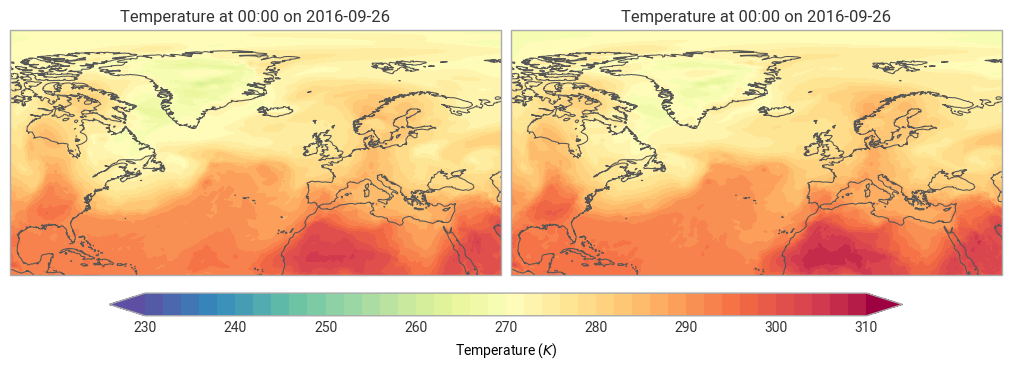

In [4]:
ekp.quickplot(t_res.isel(valid_time=0))